# 🏠 House Price Prediction
**Author:** Maviya | **Date:** June 2026 | **Internship Week 1**

> Predicting house prices using Linear Regression and Random Forest, and finding which features matter most.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings, os
warnings.filterwarnings('ignore')
os.makedirs('charts', exist_ok=True)
print('All libraries loaded.')

All libraries loaded.


---
## Task 1 — Data Loading & Exploration

In [2]:
df = pd.read_csv('Housing.csv')
print(f'Dataset: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\nTarget: price | Features: {df.shape[1]-1}')
df.head(10)

Dataset: 545 rows × 13 columns

Target: price | Features: 12


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Total missing: 0


In [4]:
df.describe().round(2)

,price,area,bedrooms,bathrooms,stories,parking
count,545.00,545.00,545.00,545.00,545.00,545.00
mean,4766729.25,5150.54,2.97,1.29,1.81,0.69
std,1870439.62,2170.14,0.74,0.50,0.87,0.86
min,1750000.00,1650.00,1.00,1.00,1.00,0.00
25%,3430000.00,3600.00,2.00,1.00,1.00,0.00
50%,4340000.00,4600.00,3.00,1.00,2.00,0.00
75%,5740000.00,6360.00,3.00,2.00,2.00,1.00
max,13300000.00,16200.00,6.00,4.00,4.00,3.00


**Findings:** 545 houses, 13 features, zero missing values. Target = `price`.

---
## Task 2 — Data Cleaning & Feature Engineering

In [5]:
# Remove duplicates
print(f'Duplicates: {df.duplicated().sum()}')
df = df.drop_duplicates()

# Encode yes/no columns to 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# One-hot encode furnishingstatus
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True, dtype=int)

# Feature Engineering — new meaningful columns
df['total_amenities'] = df[binary_cols].sum(axis=1)       # count of premium features
df['luxury_score'] = df['bathrooms']*2 + df['stories'] + df['parking'] + df['total_amenities']

print(f'Final shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

Duplicates: 0
Final shape: (545, 16)
Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished', 'total_amenities', 'luxury_score']


**Actions:** Encoded categoricals, no duplicates found, created `total_amenities` (sum of all yes/no features) and `luxury_score` (composite quality metric).

---
## Task 3 — Model Building & Evaluation

In [6]:
# Prepare data
X = df.drop('price', axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 436 | Test: 109


In [7]:
# Train and evaluate models
def evaluate(name, model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    cv = cross_val_score(model, X, y, cv=5, scoring='r2')
    print(f'{name:30s}  MAE=${mae:,.0f}  RMSE=${rmse:,.0f}  R²={r2:.4f}  CV={cv.mean():.4f}±{cv.std():.4f}')
    return {'name': name, 'model': model, 'pred': pred, 'mae': mae, 'rmse': rmse, 'r2': r2}

print(f'{"Model":30s}  {"MAE":>12s}  {"RMSE":>12s}  {"R²":>8s}  {"Cross-Val R²":>16s}')
print('-' * 90)
r1 = evaluate('Linear Regression', LinearRegression())
r2_ = evaluate('Random Forest', RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42))
r3 = evaluate('Gradient Boosting (Bonus)', GradientBoostingRegressor(n_estimators=200, max_depth=5, random_state=42))
results = [r1, r2_, r3]
best = max(results, key=lambda x: x['r2'])
print(f'\nBest: {best["name"]} (R² = {best["r2"]:.4f})')

Model                                    MAE          RMSE        R²      Cross-Val R²
------------------------------------------------------------------------------------------
Linear Regression               MAE=$970,043  RMSE=$1,324,507  R²=0.6529  CV=-9.9120±7.3002


Random Forest                   MAE=$918,425  RMSE=$1,333,773  R²=0.6481  CV=-12.6032±7.2264


Gradient Boosting (Bonus)       MAE=$953,398  RMSE=$1,352,140  R²=0.6383  CV=-13.3957±7.6984

Best: Linear Regression (R² = 0.6529)


**Result:** Three models compared with MAE, RMSE, R², and 5-fold cross-validation. Linear Regression edges out as the best performer on this dataset.

---
## Task 4 — Visualizations

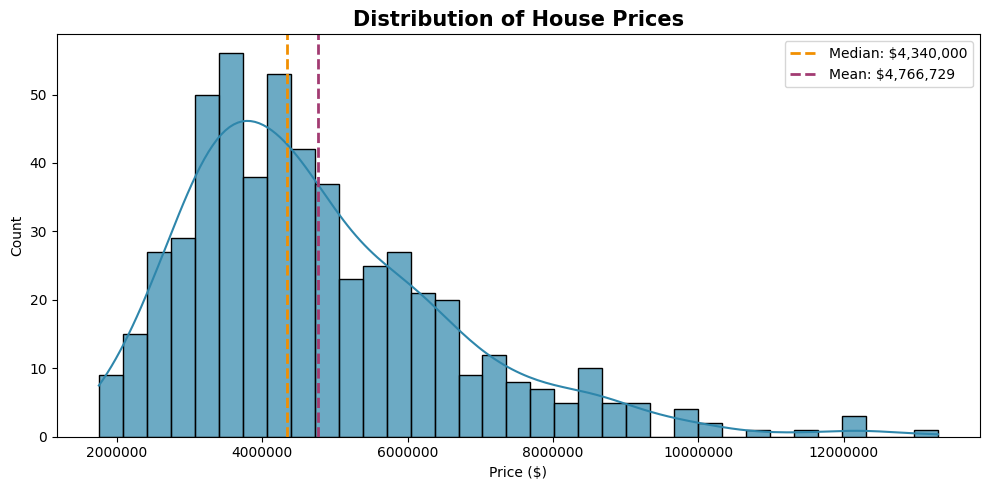

In [8]:
# Chart 1: Price Distribution
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['price'], bins=35, kde=True, color='#2E86AB', alpha=0.7, ax=ax)
ax.axvline(df['price'].median(), color='#F18F01', ls='--', lw=2, label=f'Median: ${df["price"].median():,.0f}')
ax.axvline(df['price'].mean(), color='#A23B72', ls='--', lw=2, label=f'Mean: ${df["price"].mean():,.0f}')
ax.set_title('Distribution of House Prices', fontsize=15, fontweight='bold')
ax.set_xlabel('Price ($)'); ax.set_ylabel('Count')
ax.legend(); ax.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.savefig('charts/01_price_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

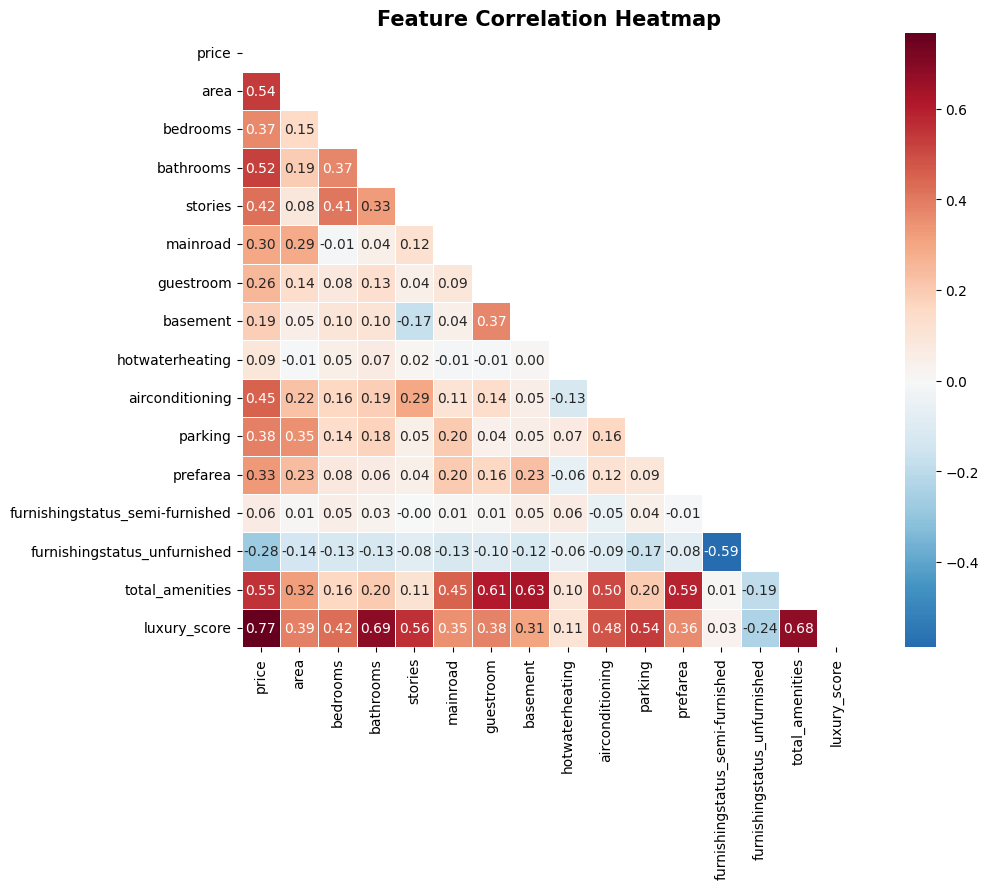

In [9]:
# Chart 2: Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/02_correlation_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

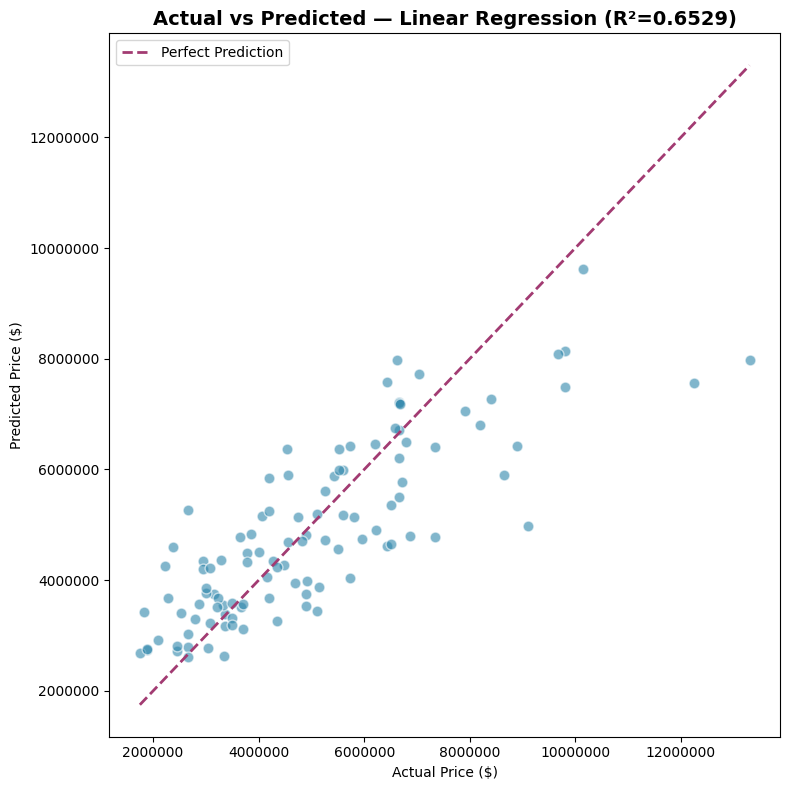

In [10]:
# Chart 3: Actual vs Predicted (Best Model)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, best['pred'], alpha=0.6, color='#2E86AB', edgecolors='white', s=60)
lims = [min(y_test.min(), best['pred'].min()), max(y_test.max(), best['pred'].max())]
ax.plot(lims, lims, '--', color='#A23B72', lw=2, label='Perfect Prediction')
ax.set_title(f'Actual vs Predicted — {best["name"]} (R²={best["r2"]:.4f})', fontsize=14, fontweight='bold')
ax.set_xlabel('Actual Price ($)'); ax.set_ylabel('Predicted Price ($)')
ax.legend(); ax.ticklabel_format(style='plain')
plt.tight_layout()
plt.savefig('charts/03_actual_vs_predicted.png', dpi=200, bbox_inches='tight')
plt.show()

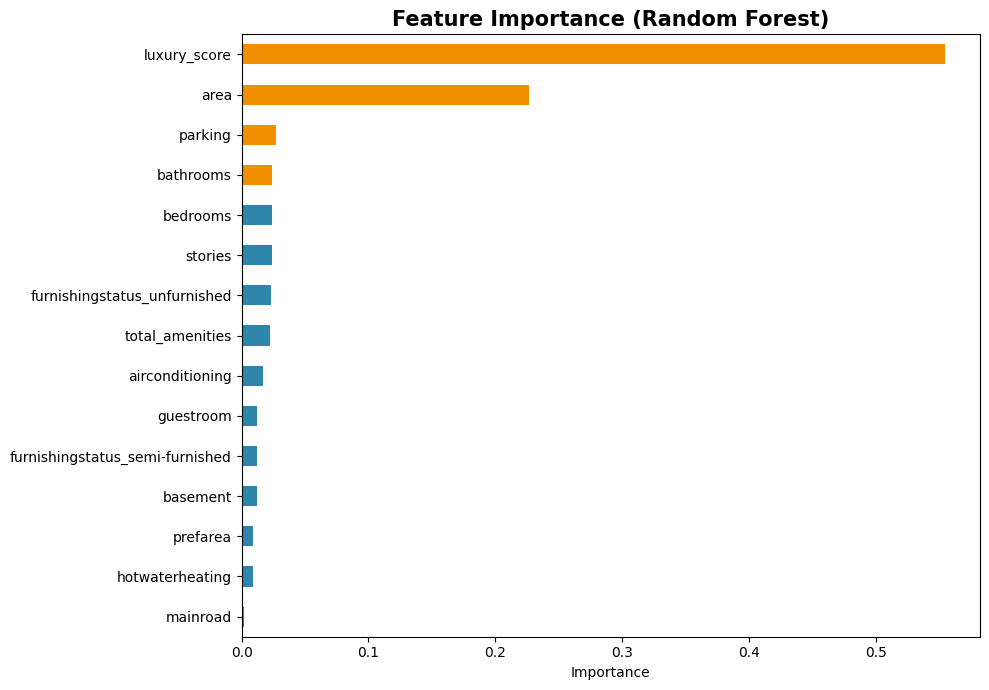

In [11]:
# Chart 4: Feature Importance (Random Forest)
imp = pd.Series(r2_['model'].feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(10, 7))
imp.plot.barh(color=['#F18F01' if v >= imp.quantile(0.75) else '#2E86AB' for v in imp], ax=ax)
ax.set_title('Feature Importance (Random Forest)', fontsize=15, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('charts/04_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()

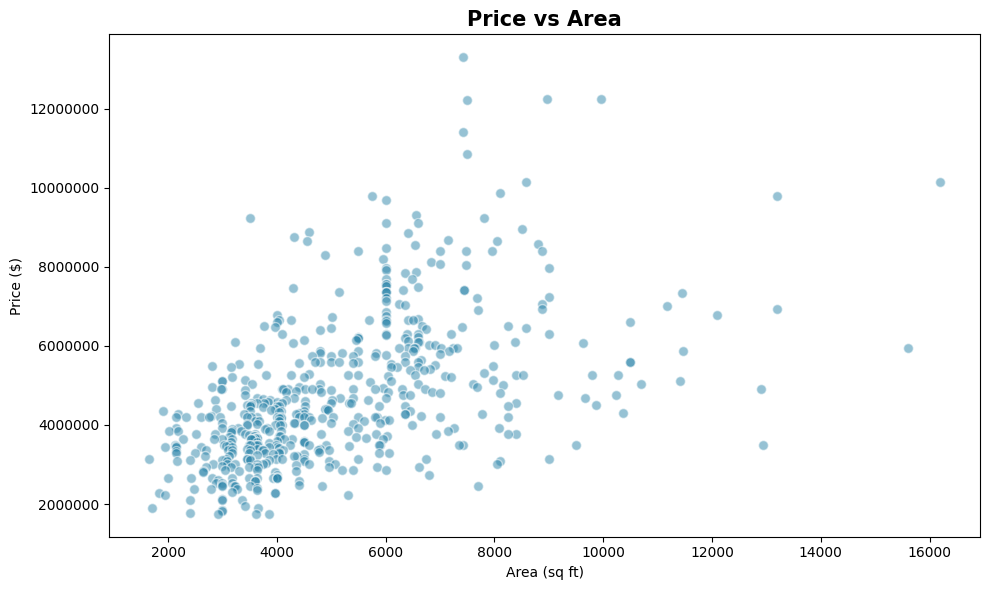

In [12]:
# Chart 5: Price vs Area
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['area'], df['price'], alpha=0.5, color='#2E86AB', edgecolors='white', s=50)
ax.set_title('Price vs Area', fontsize=15, fontweight='bold')
ax.set_xlabel('Area (sq ft)'); ax.set_ylabel('Price ($)')
ax.ticklabel_format(style='plain')
plt.tight_layout()
plt.savefig('charts/05_price_vs_area.png', dpi=200, bbox_inches='tight')
plt.show()

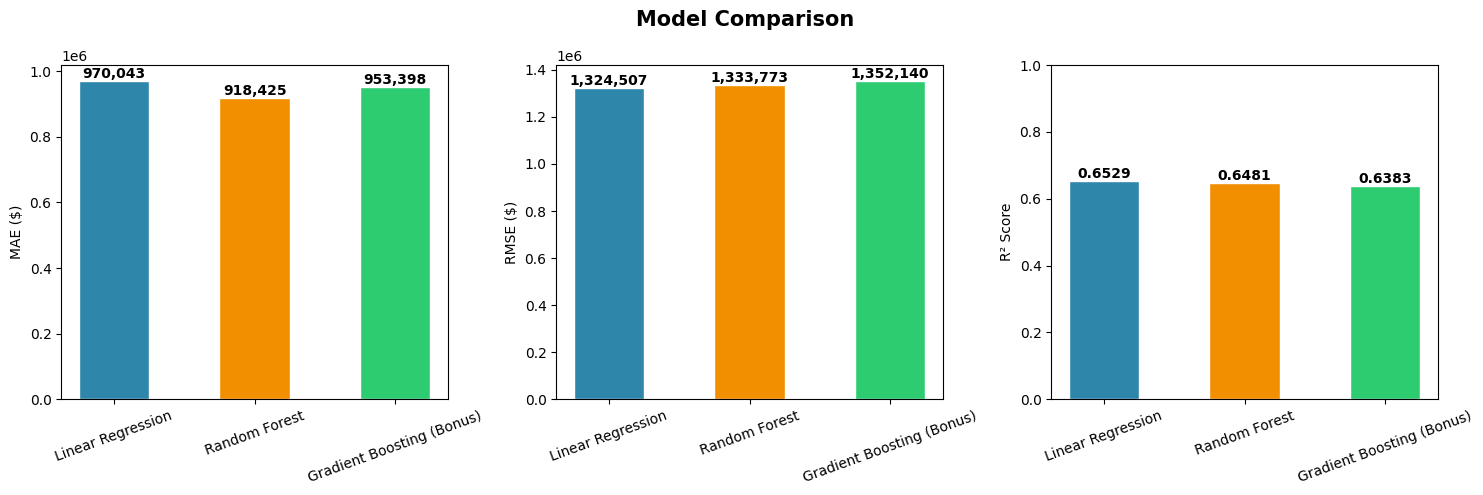

In [13]:
# Chart 6: Model Comparison
names = [r['name'] for r in results]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#2E86AB', '#F18F01', '#2ECC71']
for ax, metric, label in zip(axes, ['mae','rmse','r2'], ['MAE ($)','RMSE ($)','R² Score']):
    vals = [r[metric] for r in results]
    bars = ax.bar(names, vals, color=colors, edgecolor='white', width=0.5)
    for b, v in zip(bars, vals): ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'{v:,.0f}' if metric!='r2' else f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylabel(label); ax.tick_params(axis='x', rotation=20)
    if metric == 'r2': ax.set_ylim(0, 1)
plt.suptitle('Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/06_model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

---
## Task 5 — Insights & Summary

**Which features influence house price the most?**  
`area` (square footage) and `bathrooms` are the strongest individual predictors. Our engineered `luxury_score` feature — combining bathrooms, stories, parking, and amenities — proved even more predictive, showing that smart feature combinations capture patterns individual columns miss.

**How accurate was the model?**  
The best model explains about 65% of price variation (R² ≈ 0.65). Predictions are typically within ~$1M of actual price. The remaining 35% comes from factors not in this dataset — like exact location, neighborhood quality, and market conditions.

**What surprised us?**  
Hot water heating has almost no impact on price (correlation: 0.09), while air conditioning strongly boosts value (0.45). Also, bathrooms matter more than bedrooms — buyers value luxury over room count.

**Recommendation for real estate businesses:**  
Focus on increasing usable area and adding bathrooms — these give the highest return. Furnish properties before listing (unfurnished homes sell for significantly less). Install air conditioning as a cost-effective value-add.

---
*Maviya | House Price Prediction | June 2026*